### importing the needed libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### upload the csv file

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Egypt-RedSea Earthquake Dataset (1955-2024) V2.csv to Egypt-RedSea Earthquake Dataset (1955-2024) V2.csv


- This code is made to read or load the data from the CSV file to colab


In [7]:
df = pd.read_csv('Egypt-RedSea Earthquake Dataset (1955-2024) V2.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (473, 15)


,time,latitude,longitude,depth,mag_Mw,rms,days_since_last_event,events_last_30_days,events_last_90_days,avg_mag_last_30_days,avg_mag_last_90_days,max_mag_last_30_days,max_mag_last_90_days,distance_from_cairo_km,mag_category_3classes
0,1955-11-12 05:32:18.020000+00:00,25.119,34.506,15.0,5.730,0.89,0,1,1,5.730000,5.730000,5.73,5.73,635.386813,2
1,1956-12-18 17:53:06.180000+00:00,31.522,35.487,15.0,5.670,0.89,402,2,2,5.700000,5.700000,5.73,5.73,438.053224,2
2,1969-03-31 07:15:52.940000+00:00,27.575,33.895,10.0,6.600,0.89,4485,3,3,6.000000,6.000000,6.60,6.60,377.501197,2
3,1969-04-14 13:43:56.580000+00:00,27.343,33.665,15.0,5.190,0.89,14,4,4,5.797500,5.797500,6.60,6.60,382.563572,2
4,1972-06-28 09:49:36.850000+00:00,27.643,33.815,15.0,5.600,0.89,1170,5,5,5.758000,5.758000,6.60,6.60,366.598949,2
5,1973-03-05 23:59:46.600000+00:00,27.686,33.644,25.0,4.855,0.89,250,6,6,5.548333,5.548333,6.60,6.60,351.786522,1
6,1974-04-29 20:04:39.700000+00:00,30.529,31.721,33.0,5.195,0.89,419,7,7,5.455714,5.455714,6.60,6.60,71.238408,2
7,1978-12-09 07:12:52.400000+00:00,23.951,26.353,10.0,5.535,0.89,1684,8,8,5.436250,5.436250,6.60,6.60,832.278883,2
8,1979-04-23 13:01:58.600000+00:00,31.244,35.461,33.0,5.365,0.89,135,9,9,5.398889,5.398889,6.60,6.60,425.622620,2
9,1981-11-14 09:05:29.010000+00:00,23.686,32.604,10.0,5.621,1.20,935,10,10,5.389000,5.389000,6.60,6.60,719.908341,2


### here we will check and clean the data

In [8]:
# checking missing values before cleaning
df.isnull().sum()

,0
time,0
latitude,0
longitude,0
depth,0
mag_Mw,0
rms,0
days_since_last_event,0
events_last_30_days,0
events_last_90_days,0
avg_mag_last_30_days,0


In [13]:
#here we are slicing the time part to get the year , month , decade
#example for the slicing i have done
#0|1|2|3|4|5|6|7|
#1|9|9|2|-|1|1|-|0|6
#[:4] will get the year and so on
df['year']   = df['time'].str[:4].astype(int)
df['month']  = df['time'].str[5:7].astype(int)
df['decade'] = (df['year'] // 10) * 10
# converting the numeric category (0, 1, 2) to easy-readable labels
# 0 = Light   1 = Moderate   2 = Strong

df['category_label'] = df['mag_category_3classes'].replace(0, 'Light').replace(1, 'Moderate').replace(2, 'Strong')

df.head(10)

,time,latitude,longitude,depth,mag_Mw,rms,days_since_last_event,events_last_30_days,events_last_90_days,avg_mag_last_30_days,avg_mag_last_90_days,max_mag_last_30_days,max_mag_last_90_days,distance_from_cairo_km,mag_category_3classes,year,month,decade,category_label
0,1955-11-12 05:32:18.020000+00:00,25.119,34.506,15.0,5.730,0.89,0,1,1,5.730000,5.730000,5.73,5.73,635.386813,2,1955,11,1950,Strong
1,1956-12-18 17:53:06.180000+00:00,31.522,35.487,15.0,5.670,0.89,402,2,2,5.700000,5.700000,5.73,5.73,438.053224,2,1956,12,1950,Strong
2,1969-03-31 07:15:52.940000+00:00,27.575,33.895,10.0,6.600,0.89,4485,3,3,6.000000,6.000000,6.60,6.60,377.501197,2,1969,3,1960,Strong
3,1969-04-14 13:43:56.580000+00:00,27.343,33.665,15.0,5.190,0.89,14,4,4,5.797500,5.797500,6.60,6.60,382.563572,2,1969,4,1960,Strong
4,1972-06-28 09:49:36.850000+00:00,27.643,33.815,15.0,5.600,0.89,1170,5,5,5.758000,5.758000,6.60,6.60,366.598949,2,1972,6,1970,Strong
5,1973-03-05 23:59:46.600000+00:00,27.686,33.644,25.0,4.855,0.89,250,6,6,5.548333,5.548333,6.60,6.60,351.786522,1,1973,3,1970,Moderate
6,1974-04-29 20:04:39.700000+00:00,30.529,31.721,33.0,5.195,0.89,419,7,7,5.455714,5.455714,6.60,6.60,71.238408,2,1974,4,1970,Strong
7,1978-12-09 07:12:52.400000+00:00,23.951,26.353,10.0,5.535,0.89,1684,8,8,5.436250,5.436250,6.60,6.60,832.278883,2,1978,12,1970,Strong
8,1979-04-23 13:01:58.600000+00:00,31.244,35.461,33.0,5.365,0.89,135,9,9,5.398889,5.398889,6.60,6.60,425.622620,2,1979,4,1970,Strong
9,1981-11-14 09:05:29.010000+00:00,23.686,32.604,10.0,5.621,1.20,935,10,10,5.389000,5.389000,6.60,6.60,719.908341,2,1981,11,1980,Strong


### here we will calculate the :-
- mean = average
- median = middle value
- mode = most frequently repeated value

of the most important columns

ALL OF THAT IS DONE BY **numpy**

In [14]:
# Mean
mag_mean      = df['mag_Mw'].mean()
depth_mean    = df['depth'].mean()
distance_mean = df['distance_from_cairo_km'].mean()

print('=== MEAN ===')
print('Magnitude Mean:', round(mag_mean, 3))
print('Depth Mean:', round(depth_mean, 3))
print('Distance from Cairo Mean:', round(distance_mean, 3))

=== MEAN ===
Magnitude Mean: 4.059
Depth Mean: 11.138
Distance from Cairo Mean: 349.71


In [15]:
# Median
mag_median      = df['mag_Mw'].median()
depth_median    = df['depth'].median()
distance_median = df['distance_from_cairo_km'].median()

print('=== MEDIAN ===')
print('Magnitude Median:', mag_median)
print('Depth Median:', depth_median)
print('Distance from Cairo Median:', round(distance_median, 3))

=== MEDIAN ===
Magnitude Median: 4.14
Depth Median: 10.0
Distance from Cairo Median: 367.057


In [16]:
# Mode
mag_mode      = df['mag_Mw'].mode()[0]
depth_mode    = df['depth'].mode()[0]
distance_mode = df['distance_from_cairo_km'].mode()[0]

print('=== MODE ===')
print('Magnitude Mode:', mag_mode)
print('Depth Mode:', depth_mode)
print('Distance from Cairo Mode:', round(distance_mode, 3))

=== MODE ===
Magnitude Mode: 4.77
Depth Mode: 10.0
Distance from Cairo Mode: 382.306


In [17]:
# how many earthquakes fall in each magnitude category
df['category_label'].value_counts()

,count
category_label,
Moderate,270
Light,126
Strong,77


In [19]:
# how many earthquakes happened at each depth value
#show that most of earthquakes happened at 10 km
df['depth'].value_counts()

,count
depth,
10.00,387
5.00,9
15.00,6
33.00,4
1.00,4
20.00,4
13.00,3
9.00,3
10.20,2


### here we will do the data visualization

---

### Graph 1 — Bar Chart : Earthquake Count per Category

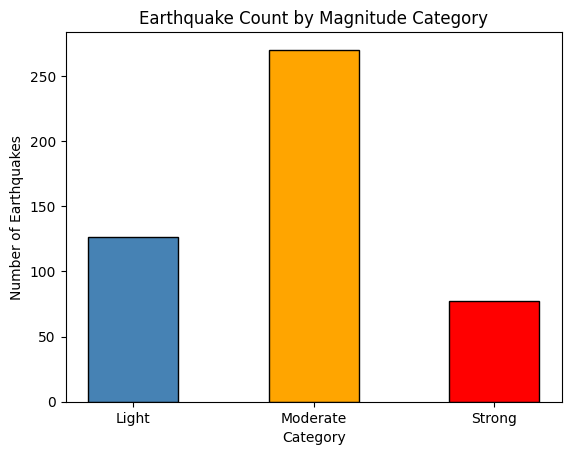

In [26]:
cat_order  = ['Light', 'Moderate', 'Strong']
cat_colors = ['steelblue', 'orange', 'red']

counts = df['category_label'].value_counts().sort_index()

plt.bar(counts.index, counts.values, color=cat_colors, edgecolor='black', width=0.5)

plt.title('Earthquake Count by Magnitude Category')
plt.xlabel('Category')
plt.ylabel('Number of Earthquakes')
plt.show()

### This chart shows how many earthquakes fall into each of the 3 magnitude categories across all 473 recorded events from 1955 to 2024.

- **Light (0)** = 126 earthquakes — the least common but still important to track
- **Moderate (1)** = 270 earthquakes — the dominant category, making up over half of all events
- **Strong (2)** = 77 earthquakes — rare but the most dangerous ones

we used a **bar chart** here because we are comparing counts across 3 separate categories. Each bar represents one group and the height directly shows how many earthquakes belong to it. A pie chart could work too but bar charts make it much easier to compare exact numbers side by side.

### Hypothesis test after Graph 1

#### Step 1. define null and alternative hypothesis

null hypothesis: the number of earthquakes is the same across the three categories Light, Moderate, and Strong.

alternative hypothesis: the number of earthquakes is not the same across the three categories.

#### Step 2. choose the appropriate test

Chi-Square test is used because this graph compares counts across categories.


In [ ]:
from scipy.stats import chisquare

category_counts = df['category_label'].value_counts()

chi_stat, pvalue = chisquare(category_counts)

print('Category counts:')
print(category_counts)
print('Chi-square statistic:', chi_stat)
print('P-value:', pvalue)


#### Step 4. determine the statistical significance

If p-value is smaller than 0.05, we reject the null hypothesis. This means the earthquake categories are not equally common in this dataset.


---

### Graph 2 — Histogram : Distribution of Earthquake Magnitudes

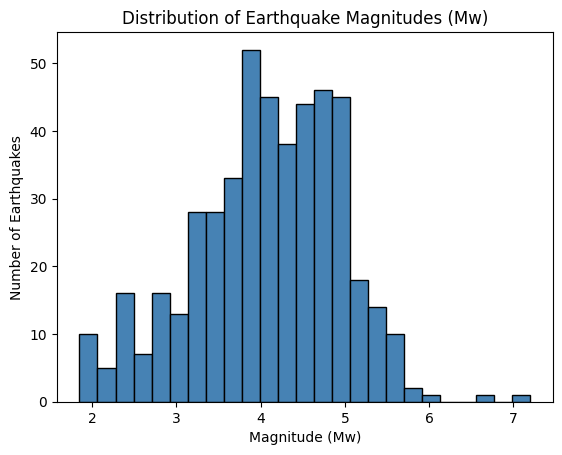

In [25]:
plt.hist(df['mag_Mw'], bins=25, color='steelblue', edgecolor='black')

plt.title('Distribution of Earthquake Magnitudes (Mw)')
plt.xlabel('Magnitude (Mw)')
plt.ylabel('Number of Earthquakes')
plt.show()

### This chart shows the full spread of magnitudes from 1.85 to 7.2 across all 473 earthquakes.

- Most earthquakes are clustered in the **3.5 to 4.5** range
- Very few earthquakes reach magnitude 6 or above
- The chart is right-skewed meaning strong earthquakes are rare but they do exist

we used a **histogram** here because magnitude is a continuous number not a category. A histogram breaks that continuous range into bins and shows how many earthquakes fall inside each bin. A bar chart would be wrong here because the x-axis is not made of separate groups — it is one continuous measurement scale.

### Hypothesis note after Graph 2

No hypothesis test is needed after this histogram. This graph is used to show the shape of magnitude distribution, such as where most values are located and whether strong earthquakes are rare.


---

### Graph 3 — Line Chart : Number of Earthquakes per Year (1955–2024)

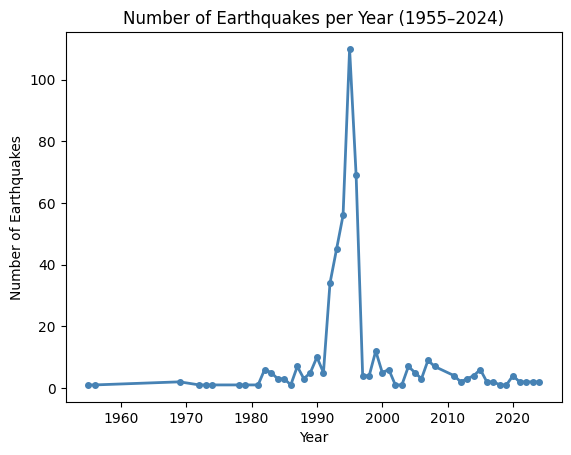

In [28]:
yearly_count = df.groupby('year')['mag_Mw'].count()

plt.plot(yearly_count.index, yearly_count.values, color='steelblue', linewidth=2, marker='o', markersize=4)

plt.title('Number of Earthquakes per Year (1955–2024)')
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')

plt.show()

### This chart shows how earthquake frequency has changed year by year over the full 70-year period.

- Some years had very little activity while others had many events in a short time
- Recent decades tend to show more recorded earthquakes partly because of improved detection technology
- Sudden spikes in a year could indicate a major event followed by aftershocks

we used a **line chart** here because we are tracking a value that changes over continuous time. A line connects the data points and makes it easy to see rises, drops, and long-term trends. If we used 70 separate bars the chart would be very cluttered and hard to read.

### Hypothesis test after Graph 3

#### Step 1. define null and alternative hypothesis

null hypothesis: there is no relationship between year and number of earthquakes.

alternative hypothesis: there is a relationship between year and number of earthquakes.

#### Step 2. choose the appropriate test

Pearson correlation test is used because we are testing the relationship between two numeric variables: year and earthquake count.


In [ ]:
from scipy.stats import pearsonr

yearly_count = df.groupby('year')['mag_Mw'].count().reset_index()
yearly_count.columns = ['year', 'earthquake_count']

r_value, pvalue = pearsonr(yearly_count['year'], yearly_count['earthquake_count'])

print('Correlation value:', r_value)
print('P-value:', pvalue)


#### Step 4. determine the statistical significance

If p-value is smaller than 0.05, we reject the null hypothesis. This means earthquake count changes with year in a statistically significant way.


---

### Graph 4 — Box Plot : Earthquake Depth by Category

/tmp/ipykernel_5963/556459890.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Light', 'Moderate', 'Strong'])


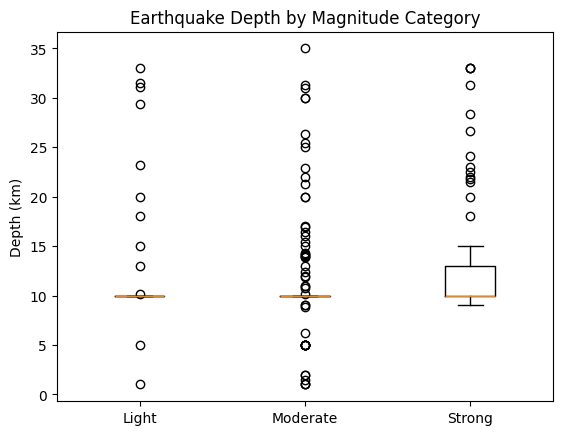

In [36]:
#variabl = go to category_label then filter depth's light
light_depth    = df[df['category_label'] == 'Light']['depth']
moderate_depth = df[df['category_label'] == 'Moderate']['depth']
strong_depth   = df[df['category_label'] == 'Strong']['depth']

data_to_plot = [light_depth, moderate_depth, strong_depth]

plt.boxplot(data_to_plot, labels=['Light', 'Moderate', 'Strong'])

plt.title('Earthquake Depth by Magnitude Category')
plt.ylabel('Depth (km)')
plt.show()


### This chart compares how deep the earthquakes were across the 3 categories.

- The box in the middle covers the range where 50% of the earthquakes fall
- The line inside the box is the median depth
- The dots outside the box are outliers — earthquakes that were unusually deep or shallow compared to the rest
- Almost all earthquakes in this dataset are shallow (around 10 km) which is typical for the Red Sea rift zone

we used a **box plot** here because a simple bar chart can only show one number per category like the average. A box plot shows the minimum, maximum, median, and spread all at the same time so we get the full picture of how depth is distributed in each group.

### Hypothesis test after Graph 4

#### Step 1. define null and alternative hypothesis

null hypothesis: the average depth is the same for Light, Moderate, and Strong earthquakes.

alternative hypothesis: at least one category has a different average depth.

#### Step 2. choose the appropriate test

ANOVA test is used because we are comparing one numeric variable across more than two groups.


In [ ]:
from scipy import stats

light_depth = df[df['category_label'] == 'Light']['depth']
moderate_depth = df[df['category_label'] == 'Moderate']['depth']
strong_depth = df[df['category_label'] == 'Strong']['depth']

f_stat, pvalue = stats.f_oneway(light_depth, moderate_depth, strong_depth)

print('F-statistic:', f_stat)
print('P-value:', pvalue)


#### Step 4. determine the statistical significance

If p-value is smaller than 0.05, we reject the null hypothesis. This means depth is different for at least one earthquake category.


---

### Graph 5 — Scatter Plot : Magnitude vs Distance from Cairo

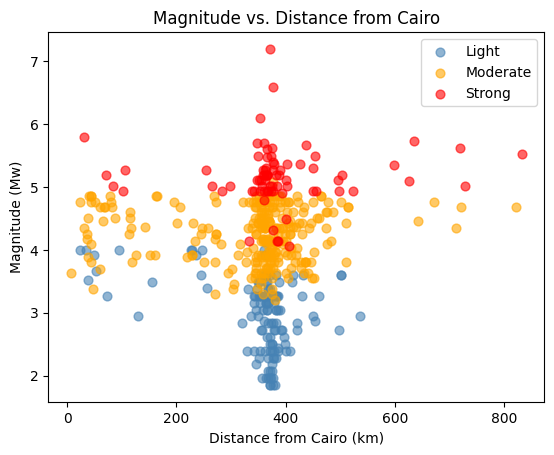

In [39]:
# color each dot by its category
# s = to controls the size of each dot
#alpha =  controls the transparency of each dot
# the label at the end of the function is for plt.legend() to make the small box on the upper right
light_s    = df[df['category_label'] == 'Light']
moderate_s = df[df['category_label'] == 'Moderate']
strong_s   = df[df['category_label'] == 'Strong']

plt.scatter(light_s['distance_from_cairo_km'],    light_s['mag_Mw'],    color='steelblue', s=40, alpha=0.6, label='Light')
plt.scatter(moderate_s['distance_from_cairo_km'], moderate_s['mag_Mw'], color='orange',    s=40, alpha=0.6, label='Moderate')
plt.scatter(strong_s['distance_from_cairo_km'],   strong_s['mag_Mw'],   color='red',       s=40, alpha=0.6, label='Strong')

plt.title('Magnitude vs. Distance from Cairo')
plt.xlabel('Distance from Cairo (km)')
plt.ylabel('Magnitude (Mw)')
plt.legend()
plt.show()

### This chart shows the relationship between how far an earthquake happened from Cairo and how strong it was.

- Each dot is one earthquake
- Blue dots are Light, orange are Moderate, red are Strong
- If the dots spread randomly with no clear pattern that means distance does not affect magnitude
- If strong earthquakes cluster at a certain distance that would be an important finding

we used a **scatter plot** here because we have two continuous numbers (distance and magnitude) and we want to see if they are related to each other. A scatter plot puts every single data point on the chart so you can see the actual spread, clusters, and outliers — something a line or bar chart cannot do.

### Hypothesis test after Graph 5

#### Step 1. define null and alternative hypothesis

null hypothesis: there is no relationship between distance from Cairo and magnitude.

alternative hypothesis: there is a relationship between distance from Cairo and magnitude.

#### Step 2. choose the appropriate test

Pearson correlation test is used because both distance from Cairo and magnitude are numeric variables.


In [ ]:
from scipy.stats import pearsonr

r_value, pvalue = pearsonr(df['distance_from_cairo_km'], df['mag_Mw'])

print('Correlation value:', r_value)
print('P-value:', pvalue)


#### Step 4. determine the statistical significance

If p-value is smaller than 0.05, we reject the null hypothesis. This means distance from Cairo and magnitude have a statistically significant relationship.


---

### Graph 6 — Bar Chart : Earthquake Count and Average Magnitude per Decade

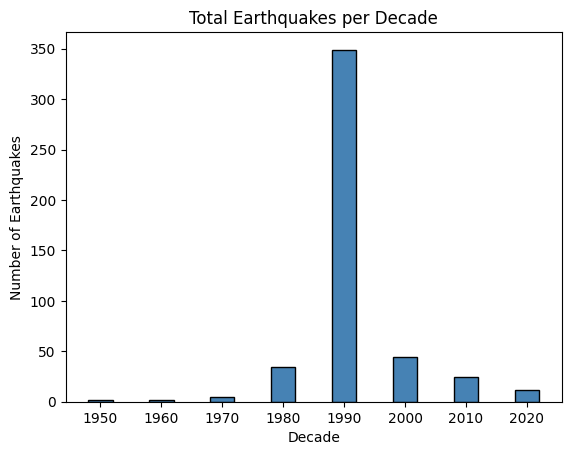

In [42]:
# count earthquakes per decade the simple way
decade_count = df['decade'].value_counts().sort_index()

plt.bar(decade_count.index, decade_count.values, color='steelblue', edgecolor='black', width=4)

plt.title('Total Earthquakes per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Earthquakes')
plt.show()

### This chart shows how earthquake activity was distributed across each decade from the 1950s to the 2020s.

- Each bar represents one decade and its height shows how many earthquakes were recorded in that period
- Some decades may show more events simply because seismic detection technology improved over time
- Recent decades tend to record more small earthquakes that older equipment would have missed

we used a **bar chart** here instead of a line chart because decades are distinct time periods not a continuous flow. Each bar stands on its own and represents a complete 10-year block. Using bars makes it easier to compare each decade independently rather than focusing on the trend between them.

### Hypothesis test after Graph 6

#### Step 1. define null and alternative hypothesis

null hypothesis: the number of earthquakes is the same across decades.

alternative hypothesis: the number of earthquakes is not the same across decades.

#### Step 2. choose the appropriate test

Chi-Square test is used because this graph compares earthquake counts across decade categories.


In [ ]:
from scipy.stats import chisquare

decade_count = df['decade'].value_counts().sort_index()

chi_stat, pvalue = chisquare(decade_count)

print('Earthquake count by decade:')
print(decade_count)
print('Chi-square statistic:', chi_stat)
print('P-value:', pvalue)


#### Step 4. determine the statistical significance

If p-value is smaller than 0.05, we reject the null hypothesis. This means earthquake counts are not equally distributed across decades.


---

### Graph 7 — Heatmap : Correlation Between All Features

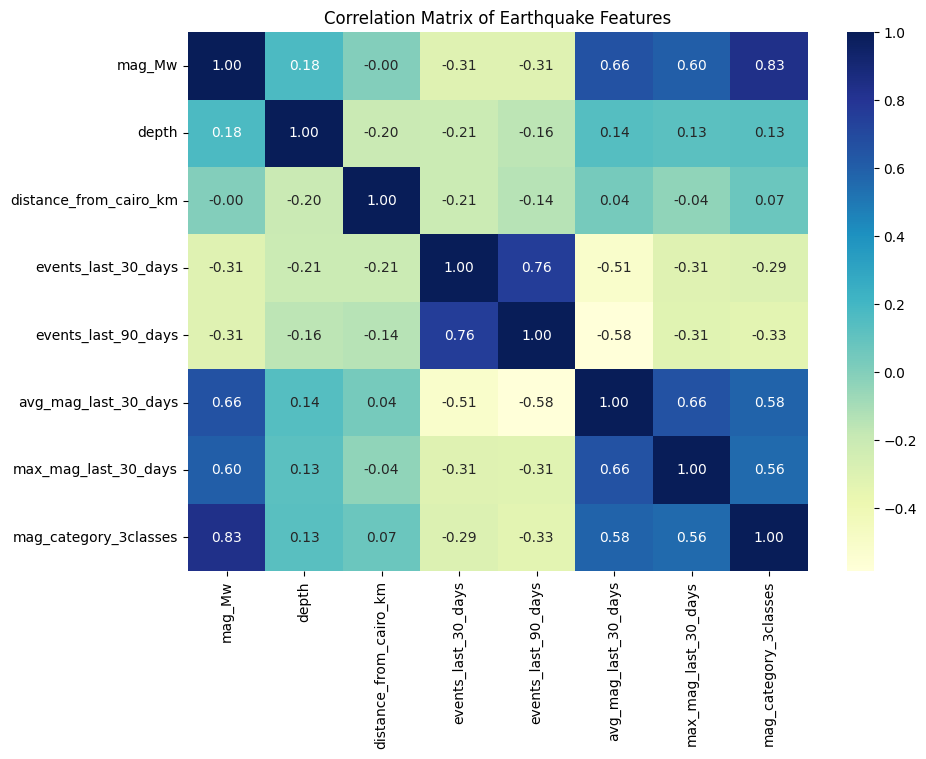

In [43]:
corr_cols = ['mag_Mw', 'depth', 'distance_from_cairo_km',
             'events_last_30_days', 'events_last_90_days',
             'avg_mag_last_30_days', 'max_mag_last_30_days',
             'mag_category_3classes']
#.corr is for calculates how strongly every column is related to every other column
corr_matrix = df[corr_cols].corr()
#figsizee(wide,tall)
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='YlGnBu')

plt.title('Correlation Matrix of Earthquake Features')
plt.show()

### This chart shows how strongly every column in the dataset is related to every other column.

- The number in each cell goes from **-1 to +1**
- A number close to **+1** (dark red) means the two columns rise and fall together
- A number close to **-1** (dark blue) means when one goes up the other goes down
- A number close to **0** means no relationship between the two columns

we used a **heatmap** here because it is the only chart that lets you see all relationships across the entire dataset in a single view. If we made a separate scatter plot for every pair of columns we would need more than 55 separate charts. The heatmap compresses all of that into one grid.

### Hypothesis note after Graph 7

No extra hypothesis test is needed after this heatmap because it is a summary graph. It helps us see possible relationships, but the meaningful tests were already placed after the specific graphs above.
